# RS Variation Comparison Plots

This notebook compares refrigerated-space infiltration variations for room temperature, refrigerant mass flow rate, and system COP over time.


In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd

# Locate project root when running from either the project root or visualization folder.
project_root = Path.cwd()
if not (project_root / "outputs").exists():
    project_root = project_root.parent

output_dir = project_root / "outputs"
figure_dir = output_dir / "comparison_plots"
figure_dir.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "axes.grid": True,
    "grid.alpha": 0.26,
    "grid.linestyle": "--",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})


In [2]:
CASE_RE = re.compile(
    r"^RS_Infiltration_Qvc(?P<qvc>[0-9]+(?:p[0-9]+)?)_"
    r"Qld(?P<qld>[0-9]+(?:p[0-9]+)?)_"
    r"(?P<openings_per_hour>[0-9]+)_door_"
    r"(?P<door_open_s>[0-9]+)s"
    r"(?:_(?P<version>[0-9]+))?\.csv$"
)


def parse_number(value):
    return float(value.replace("p", "."))


def discover_cases(output_dir):
    rows = []
    for path in sorted(output_dir.glob("RS_Infiltration_Qvc*_Qld*_door_*s*.csv")):
        match = CASE_RE.match(path.name)
        if not match:
            continue
        version = match.group("version")
        rows.append({
            "qvc": parse_number(match.group("qvc")),
            "qld": parse_number(match.group("qld")),
            "openings_per_hour": int(match.group("openings_per_hour")),
            "door_open_s": int(match.group("door_open_s")),
            "version": int(version) if version is not None else 0,
            "modified": path.stat().st_mtime,
            "path": path,
        })
    if not rows:
        raise FileNotFoundError(f"No RS infiltration CSV files found in {output_dir}")

    cases = pd.DataFrame(rows)
    cases = cases.sort_values([
        "qvc", "qld", "openings_per_hour", "door_open_s", "version", "modified"
    ])

    # Keep one file per parameter set. This handles both unversioned files and _1/_2 suffixes.
    cases = cases.drop_duplicates(
        ["qvc", "qld", "openings_per_hour", "door_open_s"],
        keep="last",
    ).reset_index(drop=True)
    return cases


cases = discover_cases(output_dir)
cases


,qvc,qld,openings_per_hour,door_open_s,version,modified,path
0,100.0,15.0,4,12,1,1.781068e+09,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...
1,100.0,15.0,4,20,1,1.781068e+09,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...
2,100.0,15.0,4,30,1,1.781068e+09,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...
3,100.0,20.0,4,12,1,1.781068e+09,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...
4,100.0,20.0,4,20,1,1.781068e+09,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...
5,100.0,20.0,4,30,1,1.781068e+09,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...
6,100.0,25.0,2,12,1,1.781067e+09,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...
7,100.0,25.0,2,20,1,1.781067e+09,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...
8,100.0,25.0,2,30,1,1.781067e+09,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...
9,100.0,25.0,4,12,1,1.781067e+09,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...


In [3]:
PLOT_COLUMNS = [
    ("room_c", "T_room (deg C)"),
    ("m_ref_kg_s", "Refrigerant mass flow rate (kg/s)"),
    ("cop_system", "System COP"),
]


def select_cases(qvc=None, qld=None, openings_per_hour=None, door_open_s=None):
    selected = cases.copy()
    if qvc is not None:
        selected = selected[selected["qvc"] == float(qvc)]
    if qld is not None:
        selected = selected[selected["qld"] == float(qld)]
    if openings_per_hour is not None:
        selected = selected[selected["openings_per_hour"] == int(openings_per_hour)]
    if door_open_s is not None:
        selected = selected[selected["door_open_s"] == int(door_open_s)]
    return selected.sort_values(["qvc", "qld", "openings_per_hour", "door_open_s"])


def read_timeseries(path):
    usecols = ["time_s", "room_c", "m_ref_kg_s", "cop_system"]
    df = pd.read_csv(path, usecols=lambda col: col in usecols)
    missing = sorted(set(usecols) - set(df.columns))
    if missing:
        raise ValueError(f"{path.name} is missing columns: {missing}")
    df = df[usecols].apply(pd.to_numeric, errors="coerce").dropna()
    df["time_min"] = df["time_s"] / 60.0
    return df


def format_load(value):
    return f"{value:g}"


def plot_timeseries_comparison(selected, label_func, title, save_name, xlim_min=None):
    if selected.empty:
        raise ValueError(f"No cases found for: {title}")

    fig, axes = plt.subplots(3, 1, figsize=(9, 8.2), sharex=True)
    colors = plt.cm.tab10.colors

    for case_index, (_, case) in enumerate(selected.iterrows()):
        df = read_timeseries(case["path"])
        label = label_func(case)
        color = colors[case_index % len(colors)]

        for ax, (column, ylabel) in zip(axes, PLOT_COLUMNS):
            ax.plot(df["time_min"], df[column], linewidth=1.7, color=color, label=label)
            ax.set_ylabel(ylabel)
            if xlim_min is not None:
                ax.set_xlim(0, xlim_min)

    axes[0].legend(loc="best", frameon=False, ncol=2)
    axes[-1].set_xlabel("Time (min)")
    fig.suptitle(title, fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.965])

    output_path = figure_dir / save_name
    fig.savefig(output_path, bbox_inches="tight")
    print(f"Saved {output_path}")
    plt.show()


def plot_timeseries_matrix_comparison(selected, label_func, title, save_name, xlim_min=None):
    if selected.empty:
        raise ValueError(f"No cases found for: {title}")

    selected = selected.reset_index(drop=True)
    fig, axes = plt.subplots(
        len(PLOT_COLUMNS),
        len(selected),
        figsize=(12, 8.2),
        sharex=True,
        sharey="row",
    )

    if len(selected) == 1:
        axes = axes.reshape(len(PLOT_COLUMNS), 1)

    for col_index, (_, case) in enumerate(selected.iterrows()):
        df = read_timeseries(case["path"])
        label = label_func(case)

        for row_index, (column, ylabel) in enumerate(PLOT_COLUMNS):
            ax = axes[row_index, col_index]
            ax.plot(df["time_min"], df[column], linewidth=1.65, color="tab:blue")
            if col_index == 0:
                ax.set_ylabel(ylabel)
            if row_index == 0:
                ax.set_title(label)
            if row_index == len(PLOT_COLUMNS) - 1:
                ax.set_xlabel("Time (min)")
            if xlim_min is not None:
                ax.set_xlim(0, xlim_min)

    fig.suptitle(title, fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.955])

    output_path = figure_dir / save_name
    fig.savefig(output_path, bbox_inches="tight")
    print(f"Saved {output_path}")
    plt.show()


## 1. Door Openings Per Hour

Compare 2, 4, and 8 door openings per hour using Qvc100, Qld25, and 12 s door-open time.


,qvc,qld,openings_per_hour,door_open_s,path
6,100.0,25.0,2,12,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...
9,100.0,25.0,4,12,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...
12,100.0,25.0,8,12,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...


Saved c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic\outputs\comparison_plots\comparison_door_openings_per_hour_Qvc100_Qld25_12s.png


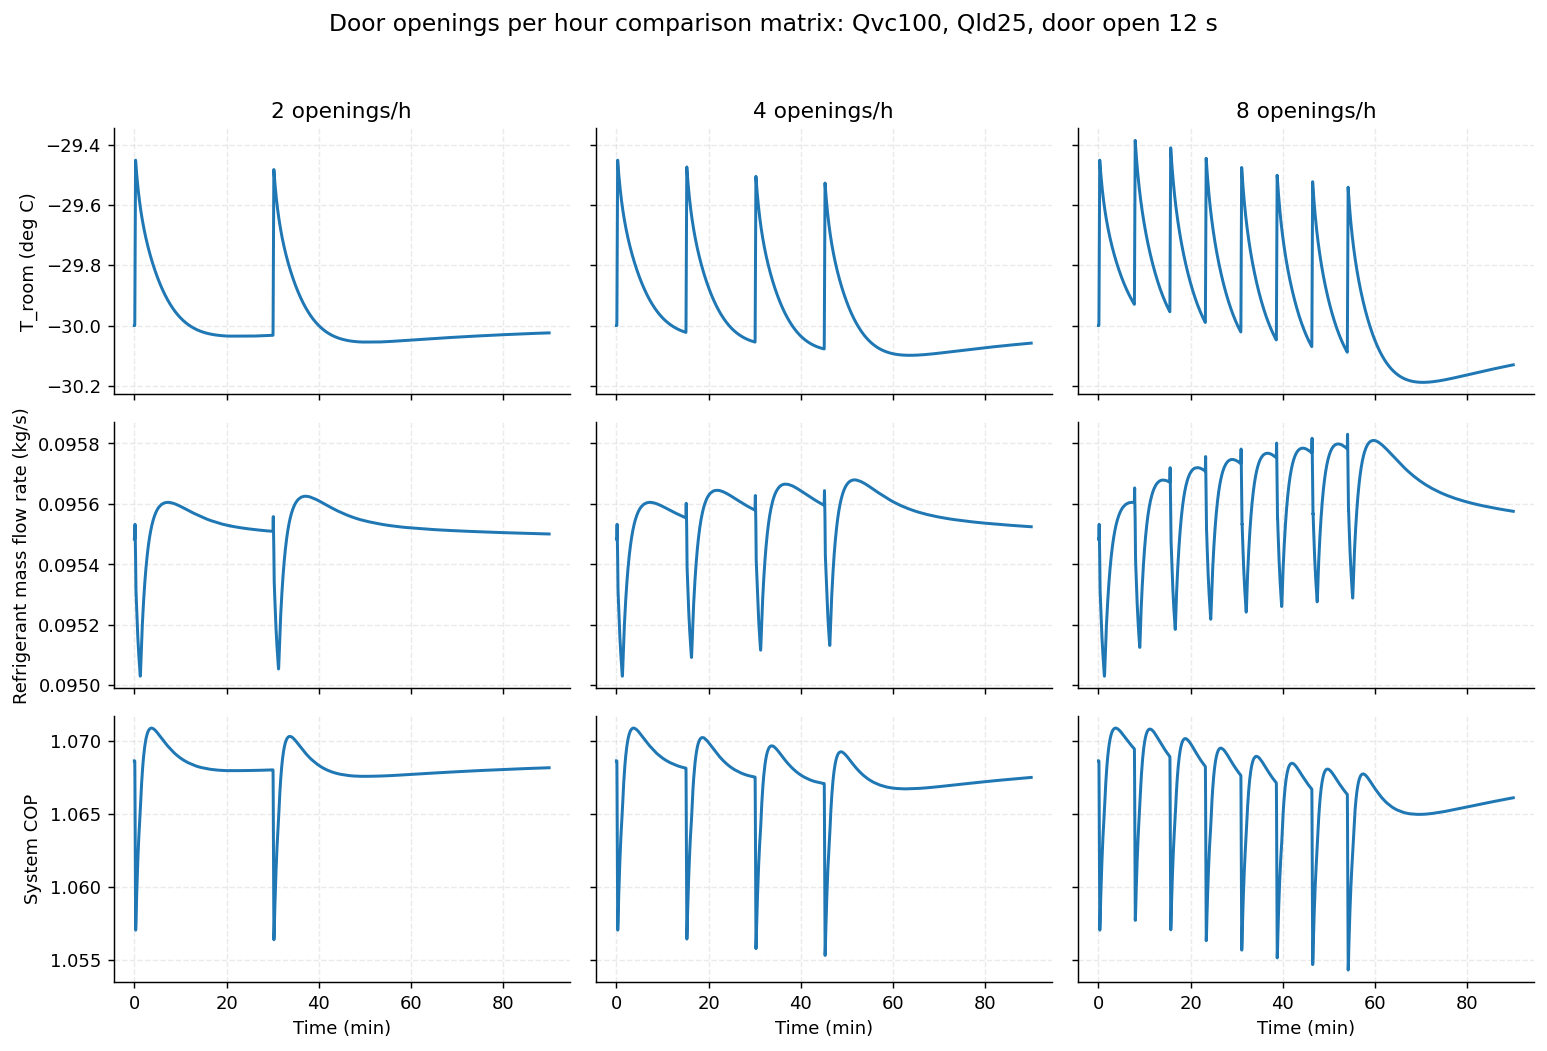

In [4]:
door_frequency_cases = select_cases(qvc=100, qld=25, door_open_s=12)
door_frequency_cases = door_frequency_cases[
    door_frequency_cases["openings_per_hour"].isin([2, 4, 8])
]

display(door_frequency_cases[["qvc", "qld", "openings_per_hour", "door_open_s", "path"]])

plot_timeseries_matrix_comparison(
    door_frequency_cases,
    label_func=lambda case: f"{int(case['openings_per_hour'])} openings/h",
    title="Door openings per hour comparison matrix: Qvc100, Qld25, door open 12 s",
    save_name="comparison_door_openings_per_hour_Qvc100_Qld25_12s.png",
)


## 2. Door-Open Time

Compare door-open durations using Qvc100, Qld25, and 4 door openings per hour.


,qvc,qld,openings_per_hour,door_open_s,path
9,100.0,25.0,4,12,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...
10,100.0,25.0,4,20,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...
11,100.0,25.0,4,30,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...


Saved c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic\outputs\comparison_plots\comparison_door_open_time_Qvc100_Qld25_4openings.png


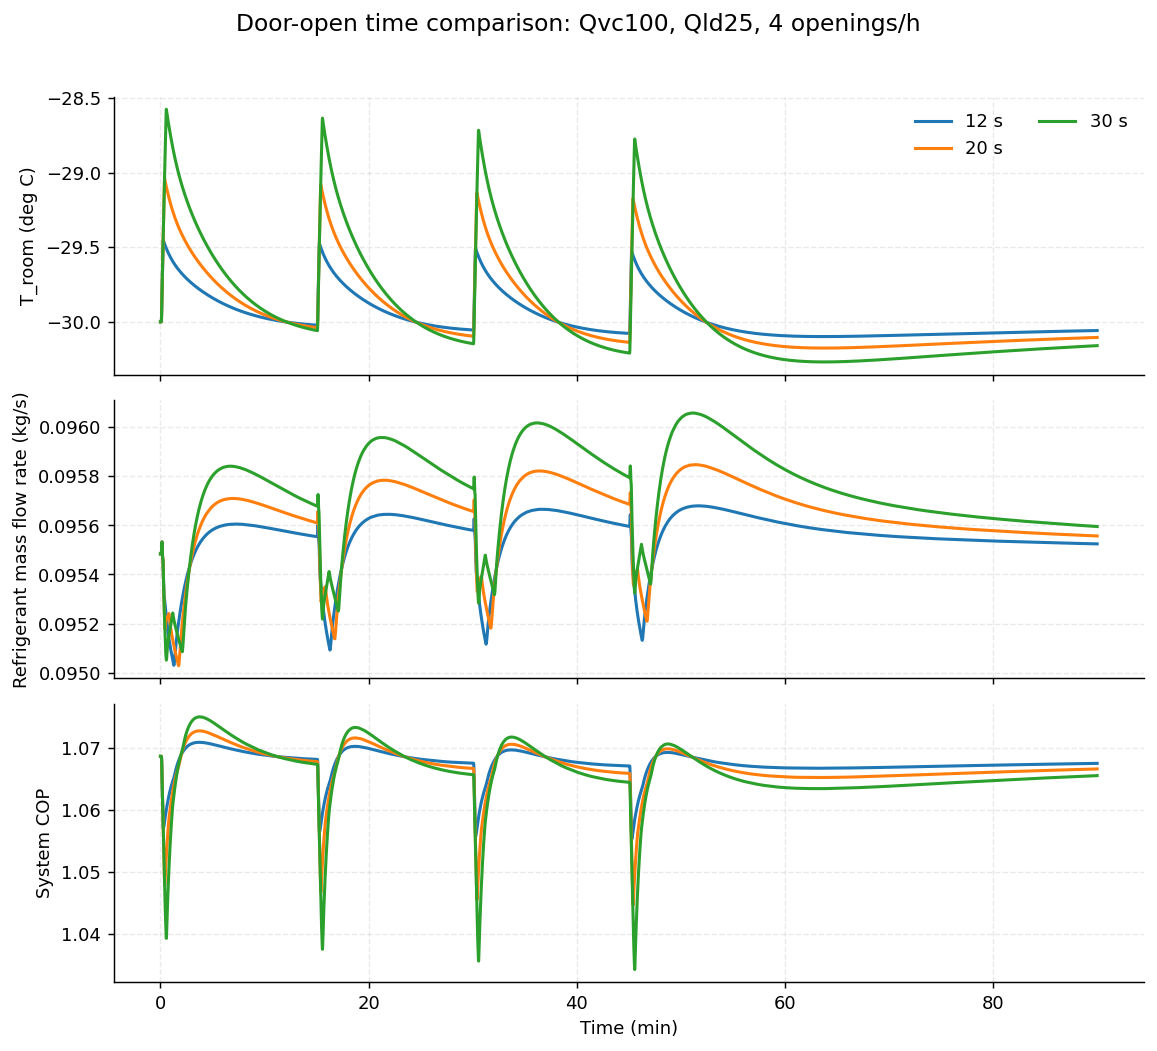

In [5]:
door_time_cases = select_cases(qvc=100, qld=25, openings_per_hour=4)
door_time_cases = door_time_cases[
    door_time_cases["door_open_s"].isin([12, 20, 30])
]

display(door_time_cases[["qvc", "qld", "openings_per_hour", "door_open_s", "path"]])

plot_timeseries_comparison(
    door_time_cases,
    label_func=lambda case: f"{int(case['door_open_s'])} s",
    title="Door-open time comparison: Qvc100, Qld25, 4 openings/h",
    save_name="comparison_door_open_time_Qvc100_Qld25_4openings.png",
)


## 3. Qvc/Qld Load Variation

Compare available Qvc/Qld cases using 4 door openings per hour and 12 s door-open time.


,qvc,qld,openings_per_hour,door_open_s,path
0,100.0,15.0,4,12,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...
3,100.0,20.0,4,12,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...
9,100.0,25.0,4,12,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...


Saved c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic\outputs\comparison_plots\comparison_Qvc_Qld_4openings_12s.png


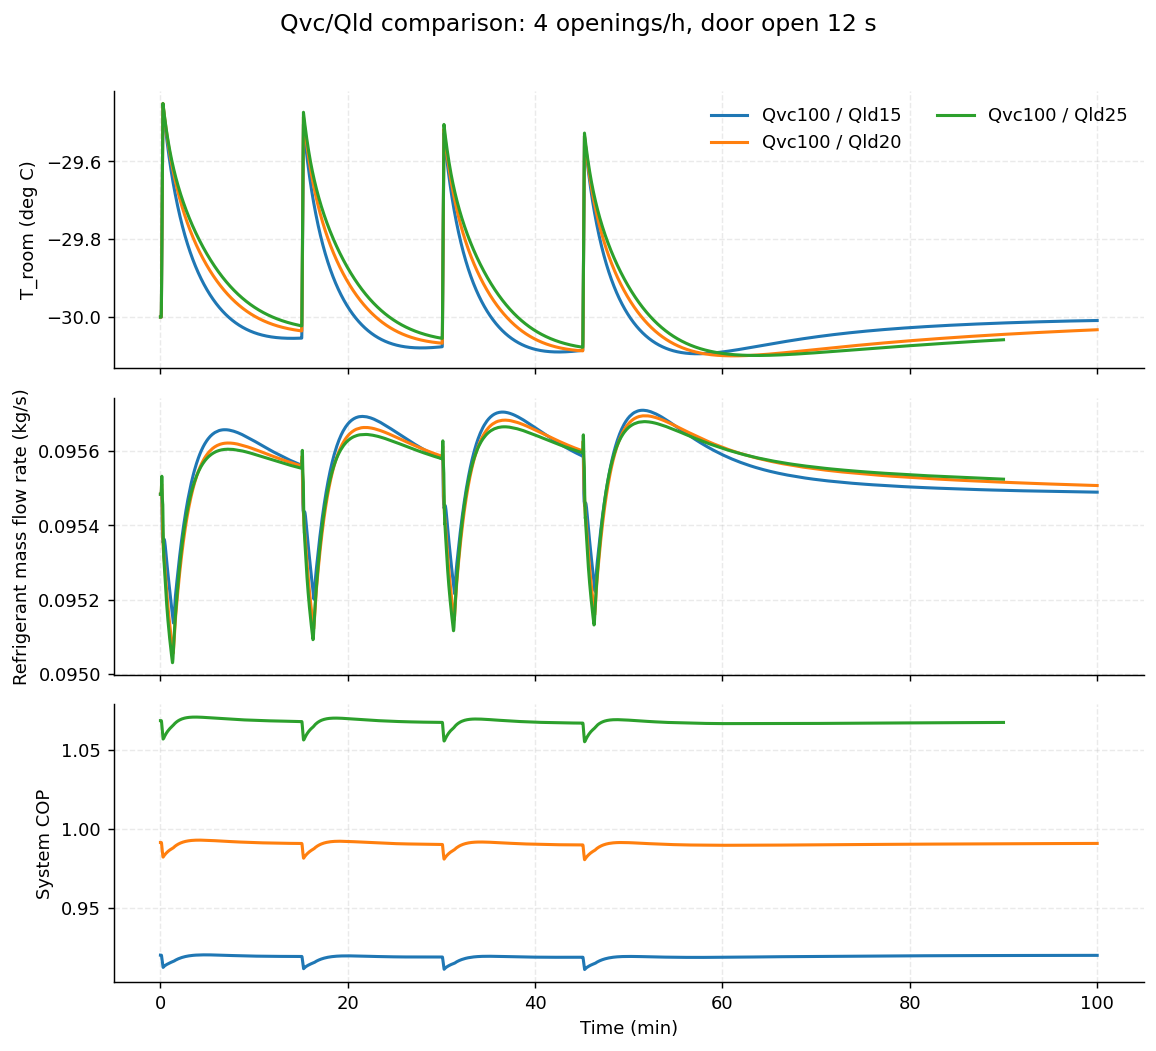

In [6]:
load_cases = select_cases(openings_per_hour=4, door_open_s=12)

display(load_cases[["qvc", "qld", "openings_per_hour", "door_open_s", "path"]])

plot_timeseries_comparison(
    load_cases,
    label_func=lambda case: f"Qvc{format_load(case['qvc'])} / Qld{format_load(case['qld'])}",
    title="Qvc/Qld comparison: 4 openings/h, door open 12 s",
    save_name="comparison_Qvc_Qld_4openings_12s.png",
)
